In [13]:
import sys
import os

sys.path.append('/home/geonyoung_lee/fab_scope/ml/train')

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from skimage.transform import resize as sk_resize

from dataset import WM811KDataset
from model import WaferClassifier

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available")

DEVICE = torch.device('cuda')
print('device:', DEVICE)

device: cuda


In [14]:
"""
test set 로드
- data/processed/X_test.npy, y_test.npy는 리사이즈/one-hot 미적용 원본 waferMap (notebooks/01_eda.ipynb 참고)
- resize(64x64) + 3채널 one-hot 변환은 WM811KDataset이 __getitem__ 시점에 수행 (train.py와 동일 로직)
"""
PROCESSED_DIR = '/home/geonyoung_lee/fab_scope/data/processed'
CHECKPOINT_PATH = '/home/geonyoung_lee/fab_scope/ml/checkpoints/best_model.pt'

FAILURE_CLASSES = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']
label_to_idx = {label: i for i, label in enumerate(FAILURE_CLASSES)}

test_maps = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'), allow_pickle=True)
test_labels_str = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'), allow_pickle=True)
test_labels = np.array([label_to_idx[l] for l in test_labels_str])

test_ds = WM811KDataset(test_maps, test_labels, augment=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=4)

print(f'test 샘플 수: {len(test_labels):,}개')

test 샘플 수: 17,282개


In [15]:
"""
학습된 best model 로드 후 test set 전체에 대해 추론
- confidence = softmax 확률 중 예측 클래스의 확률값 (모델이 그 예측을 얼마나 확신하는지)
"""
model = WaferClassifier(num_classes=len(FAILURE_CLASSES), pretrained=False).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

y_true, y_pred, y_conf = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        probs = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(pred.cpu().numpy())
        y_conf.extend(conf.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

print(f'전체 정확도: {(y_true == y_pred).mean():.4f}')

/home/geonyoung_lee/fab_scope_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/geonyoung_lee/fab_scope_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


전체 정확도: 0.9811


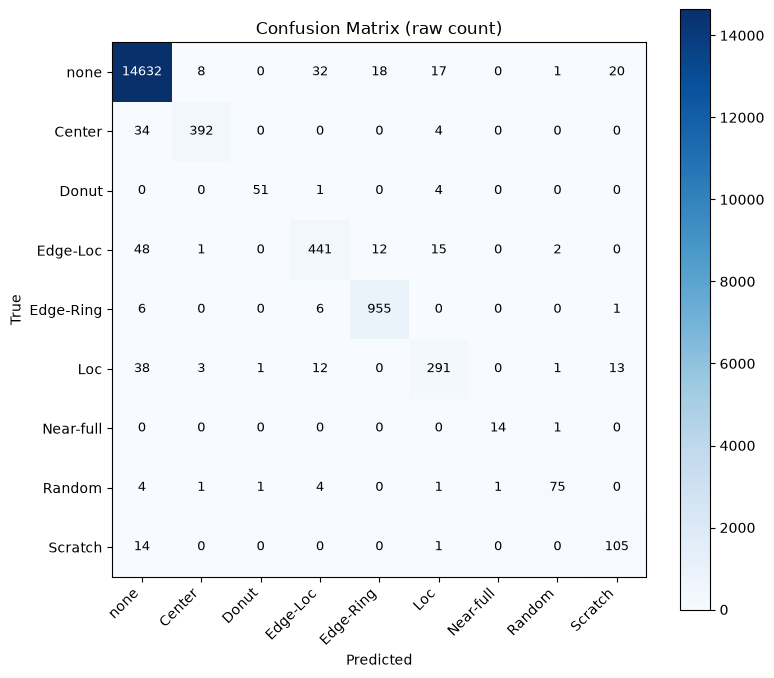

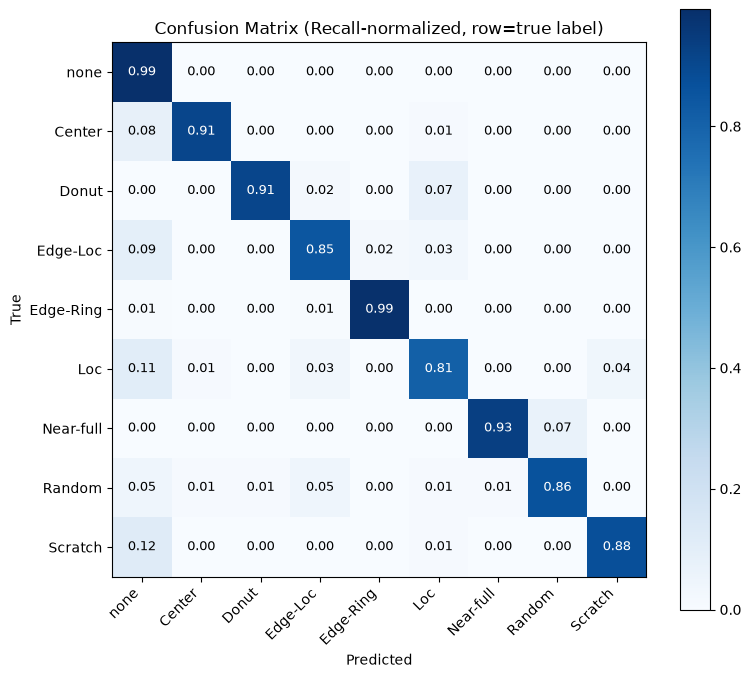

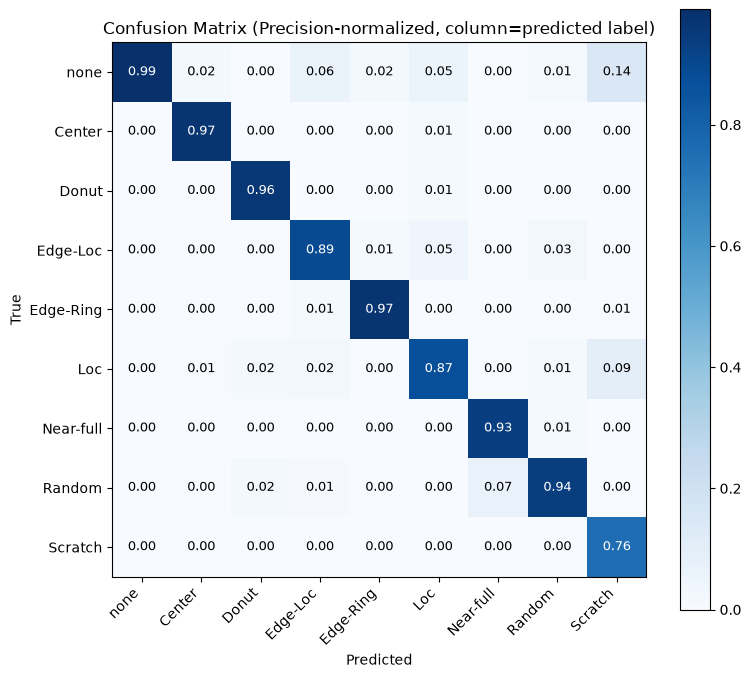

In [16]:
"""
9x9 confusion matrix - raw count / Recall 정규화(row=true label) / Precision 정규화(column=predicted label)
"""
cm_raw = confusion_matrix(y_true, y_pred, labels=range(len(FAILURE_CLASSES)))
cm_recall = confusion_matrix(y_true, y_pred, labels=range(len(FAILURE_CLASSES)), normalize='true')
cm_precision = confusion_matrix(y_true, y_pred, labels=range(len(FAILURE_CLASSES)), normalize='pred')


def plot_confusion_matrix(cm, title, fmt, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(len(FAILURE_CLASSES)))
    ax.set_yticks(range(len(FAILURE_CLASSES)))
    ax.set_xticklabels(FAILURE_CLASSES, rotation=45, ha='right')
    ax.set_yticklabels(FAILURE_CLASSES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            ax.text(j, i, format(value, fmt), ha='center', va='center', fontsize=9,
                    color='white' if value > thresh else 'black')

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm_raw, 'Confusion Matrix (raw count)', 'd')
plot_confusion_matrix(cm_recall, 'Confusion Matrix (Recall-normalized, row=true label)', '.2f')
plot_confusion_matrix(cm_precision, 'Confusion Matrix (Precision-normalized, column=predicted label)', '.2f')

In [17]:
"""
class별 precision / recall / F1 표
"""
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(len(FAILURE_CLASSES)), zero_division=0
)

metrics_df = pd.DataFrame({
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support,
}, index=FAILURE_CLASSES)

total_support = metrics_df['support'].sum()
macro_avg = metrics_df[['precision', 'recall', 'f1']].mean()
weighted_avg = (metrics_df[['precision', 'recall', 'f1']]
                .mul(metrics_df['support'], axis=0).sum() / total_support)

metrics_df.loc['macro avg'] = list(macro_avg) + [total_support]
metrics_df.loc['weighted avg'] = list(weighted_avg) + [total_support]

metrics_df.round(3)

,precision,recall,f1,support
none,0.990,0.993,0.992,14728.0
Center,0.968,0.912,0.939,430.0
Donut,0.962,0.911,0.936,56.0
Edge-Loc,0.889,0.850,0.869,519.0
Edge-Ring,0.970,0.987,0.978,968.0
Loc,0.874,0.811,0.841,359.0
Near-full,0.933,0.933,0.933,15.0
Random,0.938,0.862,0.898,87.0
Scratch,0.755,0.875,0.811,120.0
macro avg,0.920,0.904,0.911,17282.0


전체 오분류 샘플: 326개 / 17,282개 (1.9%)


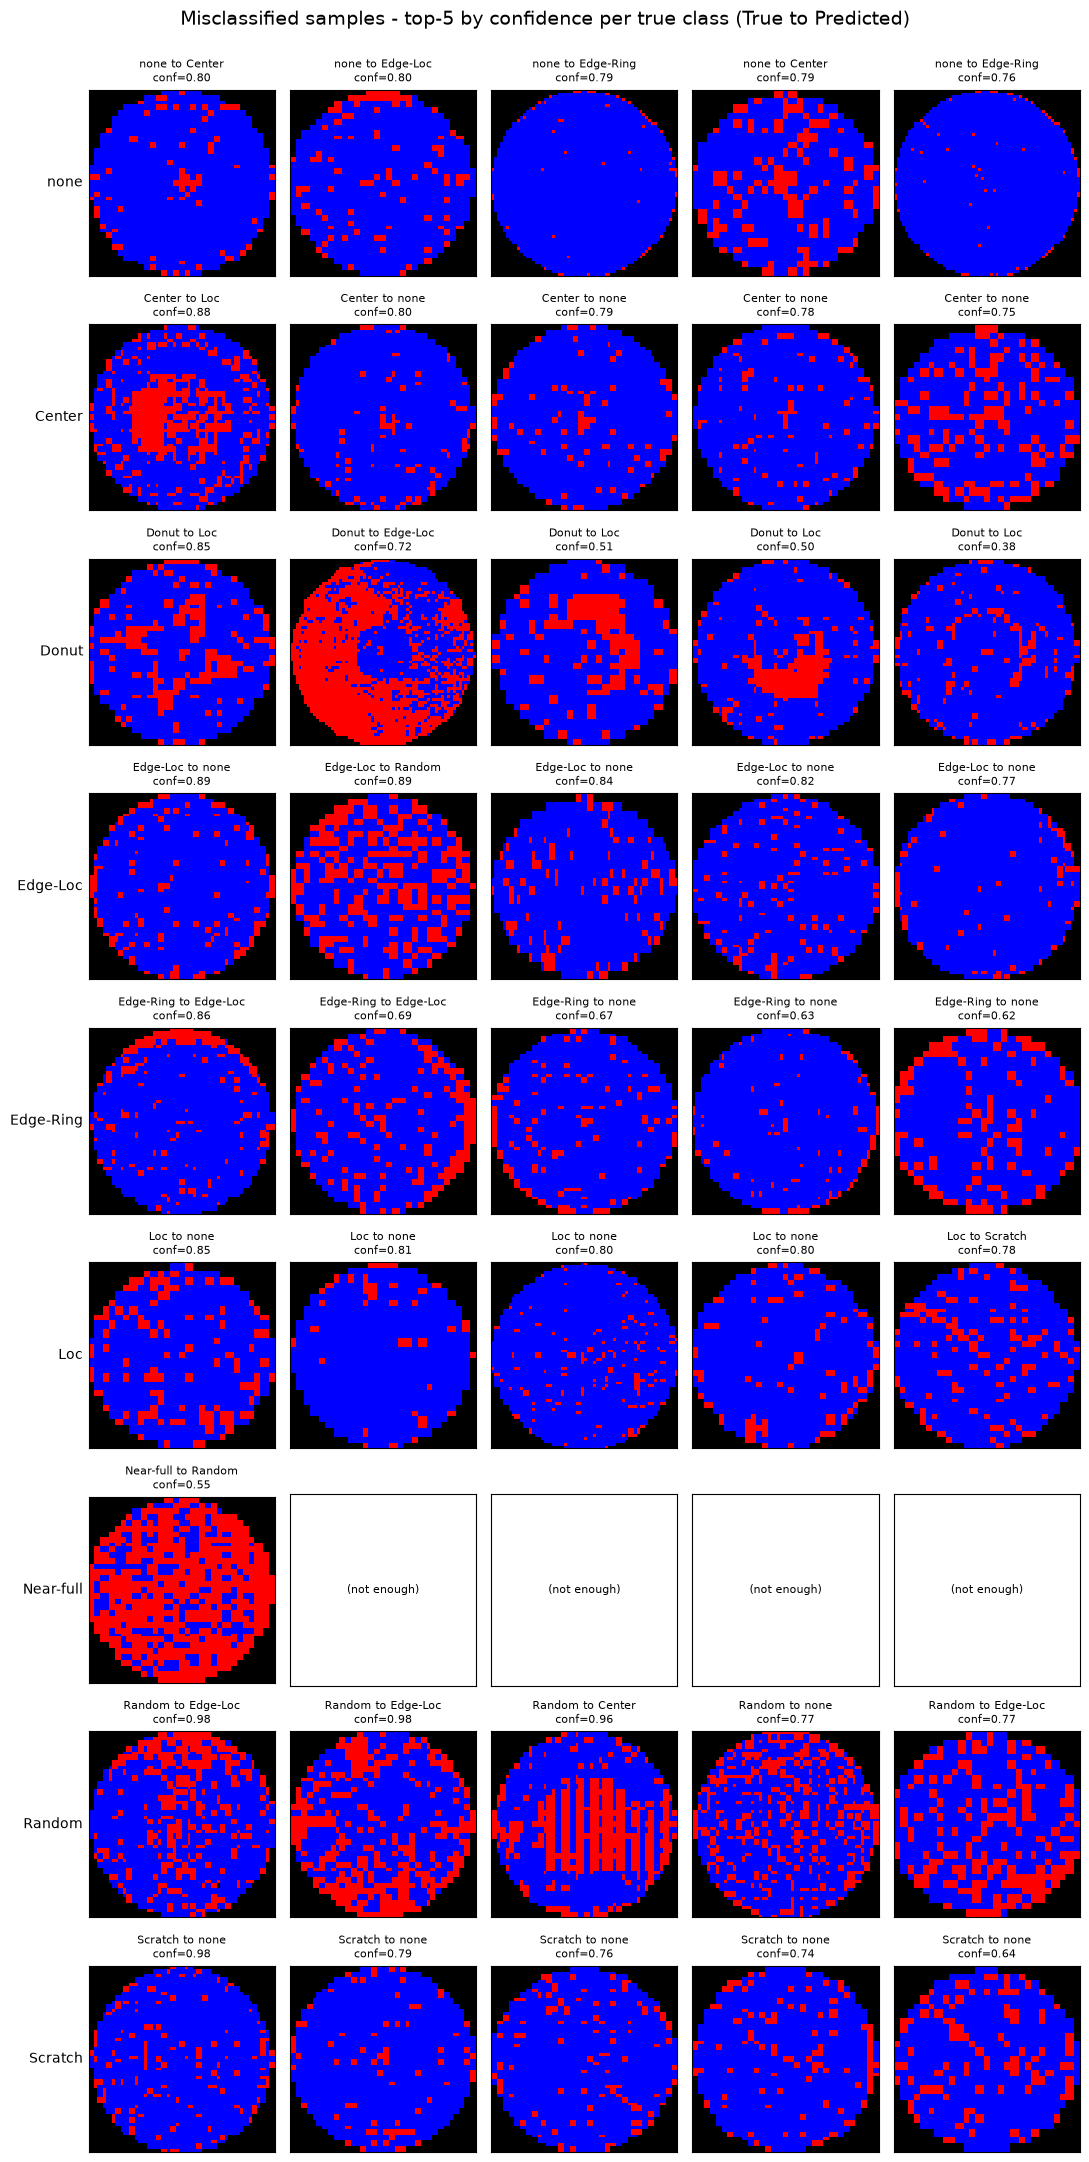

In [18]:
"""
틀린 샘플 시각화 - 어떤 패턴을 어떻게 혼동했는지

- true class(실제 failureType)별로 오분류 샘플 중 confidence(모델이 예측 클래스를 확신한 정도)가
  가장 높은 5개씩 선별 -> "모델이 확신을 갖고 틀린" 대표 사례 위주로 확인
- 시각화는 모델이 실제로 입력받은 형태(64x64, nearest-neighbor 리사이즈)로 표시
- matplotlib 기본 폰트가 한글을 지원하지 않아 플롯 안 텍스트는 영어로 표기
"""
pixel_colors = ['#000000', '#0000FF', '#FF0000']
cmap_wm = mcolors.ListedColormap(pixel_colors)
norm_wm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_wm.N)


def resize_for_view(wm, size=(64, 64)):
    return sk_resize(wm, size, order=0, preserve_range=True, anti_aliasing=False).astype(np.int8)


mis_idx_all = np.where(y_true != y_pred)[0]
print(f'전체 오분류 샘플: {len(mis_idx_all):,}개 / {len(y_true):,}개 ({len(mis_idx_all) / len(y_true) * 100:.1f}%)')

n_show = 5
fig, axes = plt.subplots(len(FAILURE_CLASSES), n_show,
                          figsize=(2.2 * n_show, 2.4 * len(FAILURE_CLASSES)))

for row, true_cls in enumerate(range(len(FAILURE_CLASSES))):
    cls_mis_idx = mis_idx_all[y_true[mis_idx_all] == true_cls]
    cls_mis_idx = cls_mis_idx[np.argsort(-y_conf[cls_mis_idx])][:n_show]  # confidence 내림차순 상위 n_show개

    for col in range(n_show):
        ax = axes[row, col]
        if col < len(cls_mis_idx):
            idx = cls_mis_idx[col]
            ax.imshow(resize_for_view(test_maps[idx]), cmap=cmap_wm, norm=norm_wm, interpolation='nearest')
            true_label = FAILURE_CLASSES[y_true[idx]]
            pred_label = FAILURE_CLASSES[y_pred[idx]]
            ax.set_title(f'{true_label} to {pred_label}\nconf={y_conf[idx]:.2f}', fontsize=8)
        else:
            ax.text(0.5, 0.5, '(not enough)', ha='center', va='center', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(FAILURE_CLASSES[true_cls], fontsize=10, rotation=0, ha='right', va='center')

plt.suptitle('Misclassified samples - top-5 by confidence per true class (True to Predicted)', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()